# Setul de date Abalone – Vizualizarea funcției de activare Tanh

Acest notebook:
1. Descarcă setul de date **Abalone** de la UCI
2. Preprocesează datele (one-hot encoding, standardizare)
3. Vizualizează **funcția tanh** și comportamentul ei pe inputurile nete ale unui neuron antrenat pe aceste date

**Definiție:**
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = 2\,\sigma(2z) - 1$$

Spre deosebire de sigmoid, tanh are ieșirea centrată în 0 (intervalul $(-1, 1)$), ceea ce accelerează convergența în rețelele neuronale.

In [1]:
# ── 1. Importuri ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print('Librăriile au fost importate cu succes.')

Librăriile au fost importate cu succes.


In [2]:
# ── 2. Descărcarea setului de date Abalone de la UCI ─────────────────────────
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
           'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv(url, header=None, names=columns)
print(f'Shape: {df.shape}')
df.head()

Shape: (4177, 9)


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [3]:
# ── 3. Preprocesare ───────────────────────────────────────────────────────────
# One-hot encoding pentru coloana 'Sex' (M, F, I)
df_enc = pd.get_dummies(df, columns=['Sex'], drop_first=False)

# Variabila țintă binară: 1 dacă Rings > median, 0 altfel
median_rings = df_enc['Rings'].median()
y = (df_enc['Rings'] > median_rings).astype(int).values
X = df_enc.drop(columns=['Rings']).values.astype(float)

# Standardizare (media=0, std=1) — ideală pentru tanh
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Median Rings: {median_rings}')

Train: (3341, 10)  |  Test: (836, 10)
Median Rings: 9.0


In [4]:
# ── 4. Antrenarea unui MLP cu activare tanh ───────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='tanh',          # <-- funcția de activare tanh
    max_iter=500,
    random_state=42
)
mlp.fit(X_train, y_train)

acc = accuracy_score(y_test, mlp.predict(X_test))
print(f'Acuratețe MLP (tanh) pe setul de test: {acc:.4f}')

Acuratețe MLP (tanh) pe setul de test: 0.8122


In [5]:
# ── 5. Definirea funcțiilor tanh, derivată și relație cu sigmoid ──────────────
def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Grilă continuă pentru curbe teoretice
z_range = np.linspace(-6, 6, 600)

# Inputurile nete ale primului strat ascuns pe setul de test
# z = X_test @ W1^T + b1
W1 = mlp.coefs_[0]      # shape (n_features, 16)
b1 = mlp.intercepts_[0] # shape (16,)
z_hidden = X_test @ W1 + b1   # shape (n_test, 16)

# Activările tanh ale primului strat
a_hidden = tanh(z_hidden)      # shape (n_test, 16)

print(f'z_hidden shape: {z_hidden.shape}')
print(f'z_hidden min={z_hidden.min():.3f}, max={z_hidden.max():.3f}, mean={z_hidden.mean():.3f}')

z_hidden shape: (836, 16)
z_hidden min=-8.296, max=9.565, mean=-0.021


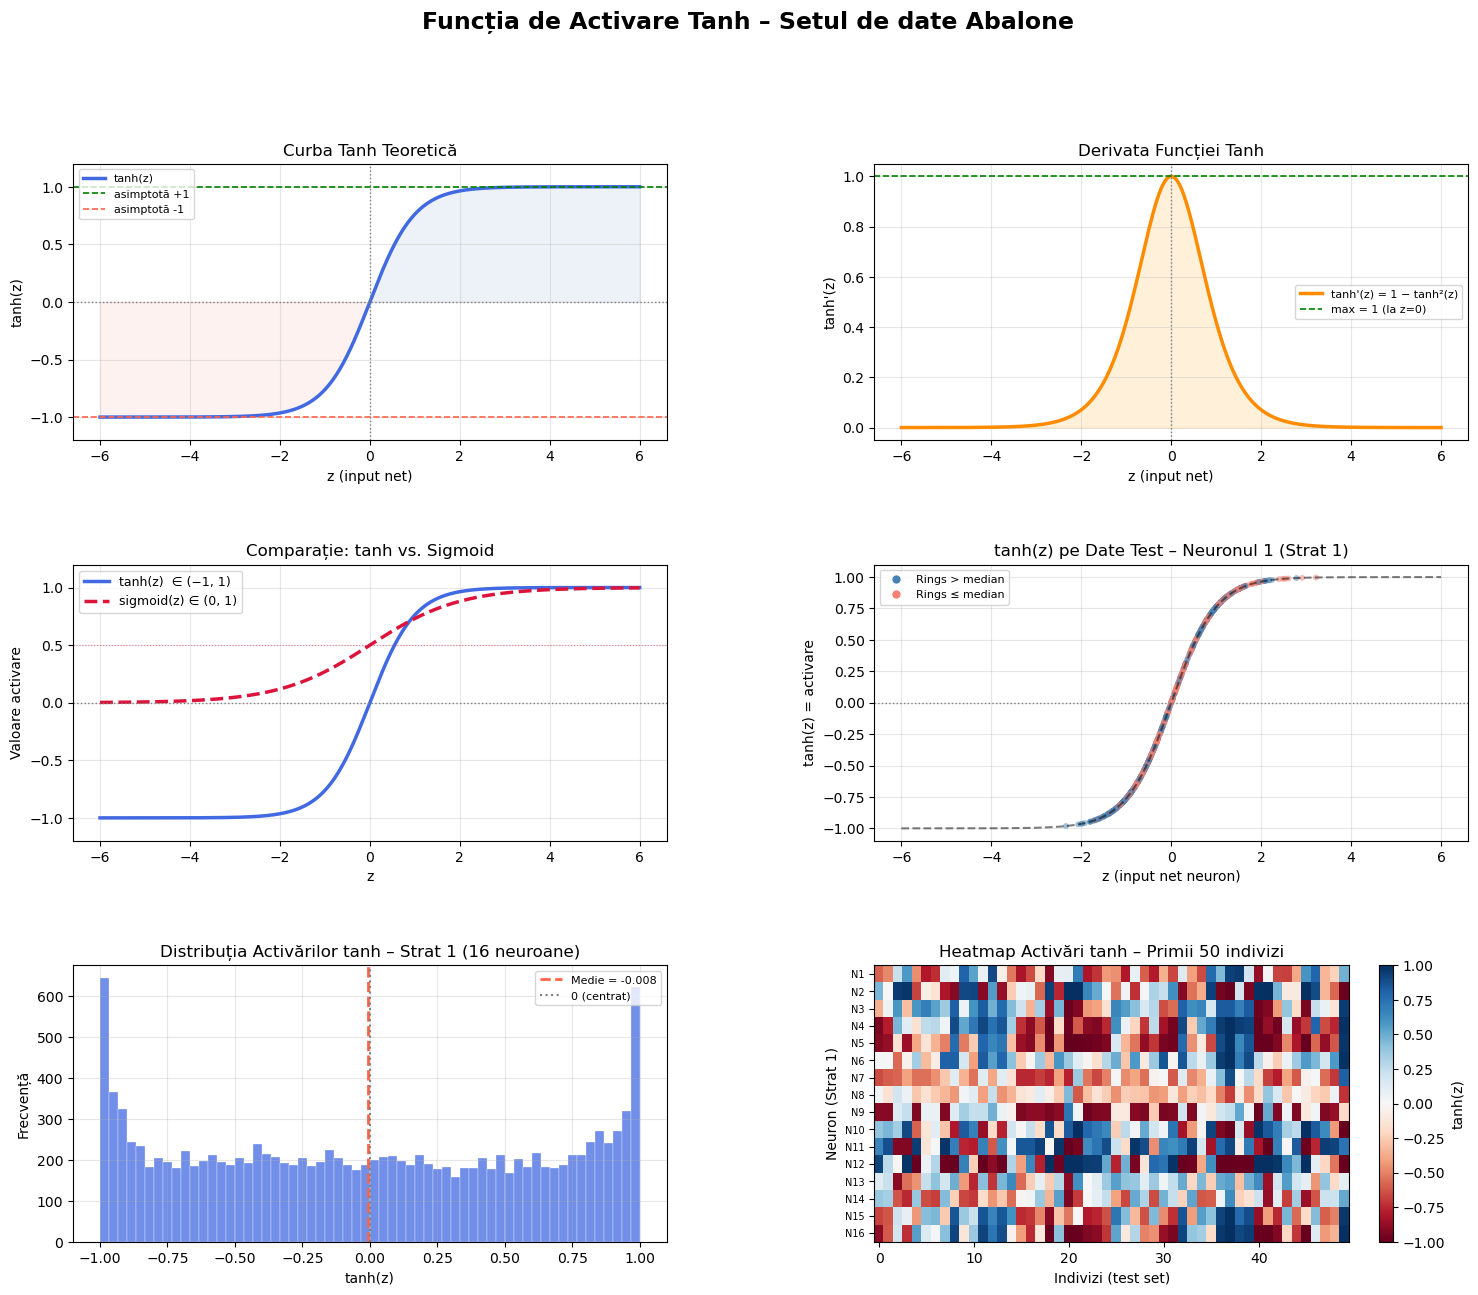

Graficul a fost salvat ca abalone_tanh.png


In [6]:
# ── 6. Vizualizare completă (6 subgrafice) ────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'Funcția de Activare Tanh – Setul de date Abalone',
    fontsize=17, fontweight='bold', y=0.99
)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── (1,1) Curba tanh teoretică ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(z_range, tanh(z_range), color='royalblue', lw=2.5, label='tanh(z)')
ax1.axhline(0,  color='gray',   ls=':',  lw=1.0)
ax1.axvline(0,  color='gray',   ls=':',  lw=1.0)
ax1.axhline( 1, color='green',  ls='--', lw=1.2, label='asimptotă +1')
ax1.axhline(-1, color='tomato', ls='--', lw=1.2, label='asimptotă -1')
ax1.fill_between(z_range, tanh(z_range), 0,
                 where=(tanh(z_range) > 0), alpha=0.10, color='steelblue')
ax1.fill_between(z_range, tanh(z_range), 0,
                 where=(tanh(z_range) < 0), alpha=0.10, color='salmon')
ax1.set_title('Curba Tanh Teoretică', fontsize=12)
ax1.set_xlabel('z (input net)')
ax1.set_ylabel('tanh(z)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1.2, 1.2)

# ── (1,2) Derivata tanh ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(z_range, tanh_derivative(z_range), color='darkorange', lw=2.5,
         label="tanh'(z) = 1 − tanh²(z)")
ax2.axvline(0, color='gray', ls=':', lw=1.0)
ax2.axhline(1, color='green', ls='--', lw=1.2, label='max = 1 (la z=0)')
ax2.fill_between(z_range, tanh_derivative(z_range), alpha=0.15, color='orange')
ax2.set_title('Derivata Funcției Tanh', fontsize=12)
ax2.set_xlabel('z (input net)')
ax2.set_ylabel("tanh'(z)")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── (2,1) Comparație tanh vs sigmoid ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(z_range, tanh(z_range),    color='royalblue',  lw=2.5, label='tanh(z)  ∈ (−1, 1)')
ax3.plot(z_range, sigmoid(z_range), color='crimson',    lw=2.5, ls='--', label='sigmoid(z) ∈ (0, 1)')
ax3.axhline(0, color='gray', ls=':', lw=1.0)
ax3.axhline(0.5, color='crimson', ls=':', lw=0.8, alpha=0.5)
ax3.set_title('Comparație: tanh vs. Sigmoid', fontsize=12)
ax3.set_xlabel('z')
ax3.set_ylabel('Valoare activare')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-1.2, 1.2)

# ── (2,2) tanh(z) pe datele de test – primul neuron ───────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
neuron_idx = 0
z_n0 = z_hidden[:, neuron_idx]
colors_map = np.where(y_test == 1, 'steelblue', 'salmon')
ax4.scatter(z_n0, tanh(z_n0), c=colors_map, alpha=0.50, s=18, edgecolors='none')
ax4.plot(z_range, tanh(z_range), color='black', lw=1.5, ls='--', alpha=0.5)
ax4.axhline(0, color='gray', ls=':', lw=1.0)
ax4.set_title(f'tanh(z) pe Date Test – Neuronul {neuron_idx+1} (Strat 1)', fontsize=12)
ax4.set_xlabel('z (input net neuron)')
ax4.set_ylabel('tanh(z) = activare')
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=7, label='Rings > median'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='salmon',    markersize=7, label='Rings ≤ median')
]
ax4.legend(handles=legend_els, fontsize=8)
ax4.grid(True, alpha=0.3)

# ── (3,1) Distribuția activărilor tanh – toate cele 16 neuroane ───────────────
ax5 = fig.add_subplot(gs[2, 0])
a_flat = a_hidden.flatten()
ax5.hist(a_flat, bins=60, color='royalblue', alpha=0.75, edgecolor='white', lw=0.3)
ax5.axvline(a_flat.mean(), color='tomato', lw=2, ls='--',
            label=f'Medie = {a_flat.mean():.3f}')
ax5.axvline(0, color='gray', lw=1.5, ls=':', label='0 (centrat)')
ax5.set_title('Distribuția Activărilor tanh – Strat 1 (16 neuroane)', fontsize=12)
ax5.set_xlabel('tanh(z)')
ax5.set_ylabel('Frecvență')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# ── (3,2) Heatmap activări tanh pe primii 50 de indivizi ─────────────────────
ax6 = fig.add_subplot(gs[2, 1])
n_show = 50
im = ax6.imshow(
    a_hidden[:n_show, :].T,
    aspect='auto', cmap='RdBu', vmin=-1, vmax=1
)
plt.colorbar(im, ax=ax6, label='tanh(z)')
ax6.set_title(f'Heatmap Activări tanh – Primii {n_show} indivizi', fontsize=12)
ax6.set_xlabel('Indivizi (test set)')
ax6.set_ylabel('Neuron (Strat 1)')
ax6.set_yticks(range(16))
ax6.set_yticklabels([f'N{i+1}' for i in range(16)], fontsize=7)

plt.savefig('abalone_tanh.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graficul a fost salvat ca abalone_tanh.png')

## Interpretarea graficelor

| Grafic | Descriere |
|--------|-----------|
| **Curba tanh teoretică** | tanh(z) ∈ (−1, 1), centrată în 0. Saturație la ±1 pentru z extreme. |
| **Derivata tanh** | tanh'(z) = 1 − tanh²(z), maximă în z=0 (valoare 1). Valori mici la extreme → *vanishing gradient*. |
| **tanh vs. Sigmoid** | tanh este o versiune scalată a sigmoid; ieșirile centrate în 0 reduc bias-ul în actualizările de gradient. |
| **tanh(z) pe date test** | Fiecare punct = un individ Abalone proiectat pe curbă prin neuronul 1 al stratului ascuns. |
| **Distribuția activărilor** | Histograma tuturor activărilor din stratul 1; centrul aproape de 0 confirmă proprietatea de zero-centering. |
| **Heatmap activări** | Vizualizare matriceală — rânduri = neuroni, coloane = indivizi. Culorile albastru/roșu arată activări negative/pozitive. |

### Avantaje tanh față de sigmoid
- **Zero-centered**: gradienții sunt mai stabili, fără bias sistematic pozitiv/negativ.
- **Gradient mai mare**: derivata maximă este 1 (față de 0.25 la sigmoid) → convergență mai rapidă.
- **Dezavantaj comun**: *vanishing gradient* la saturație (|z| mare); soluție modernă: ReLU / variante.